<img src="https://i.ibb.co/93sNcdhp/Logo-pmat-color.png" align="right" width="250">

<br>

# **Sistemas lineales $Ax=b$ en contextos aplicados**

## **Introducción**

En los laboratorios anteriores se trabajó con vectores y matrices como formas de representar información. En este laboratorio avanzaremos hacia una nueva pregunta:

¿Cómo podemos modelar relaciones entre variables desconocidas usando matrices?

Muchas situaciones reales pueden expresarse mediante sistemas de ecuaciones lineales. Por ejemplo, calcular precios unitarios, calcular costos de servicios, determinar combinaciones de recursos o analizar restricciones de un problema.

Un sistema lineal puede escribirse en forma matricial como:

$$Ax=b$$

donde:

* $A$ es la matriz de coeficientes;
* $x$ es el vector de incógnitas;
* $b$ es el vector de resultados observados.

El foco de este laboratorio no estará solo en resolver sistemas, sino en plantearlos, interpretarlos y analizar qué tipo de información entregan.

### Resultado de aprendizaje

RA2: Determina relaciones lineales en sistemas y registros vectoriales para reconocer soluciones, redundancia y similitud en contextos aplicados de ciencia de datos e inteligencia artificial, con apoyo de Python.

### Indicadores de logro

IL2.1: Construye sistemas lineales en forma $Ax=b$ a partir de restricciones de un problema contextualizado.

IL2.2: Determina variables desconocidas en sistemas lineales con solución única interpretando los valores obtenidos en contexto, con apoyo de Python cuando corresponda.

IL2.3: Determina el tipo de solución de sistemas lineales a partir del rango, interpretando si la información es suficiente, redundante o contradictoria, con apoyo de Python cuando corresponda.

In [12]:
%%html
<div style="border: 4px solid #006d77; border-radius: 0px; overflow: hidden; font-family: sans-serif; max-width: 800px; margin-bottom: 20px;">

  <div style="background-color: #000000; color: #ffc107; padding: 10px 15px; font-weight: bold; font-size: 16px; display: flex; align-items: center;">
    <span style="margin-right: 10px; font-size: 18px;">💡</span>
    <span>Traducir datos en sistemas de ecuaciones</span>
  </div>

  <div style="background-color: #ffffff; padding: 20px; display: flex; align-items: center; justify-content: space-between;">

    <div style="color: #000000; flex: 1; padding-right: 30px; font-size: 14px; line-height: 1.5;">
      Antes de comenzar las primeras actividades, revisa este recurso para comprender cómo traducir las condiciones de una situación
      a un sistema de ecuaciones, cómo organizar sus coeficientes e incógnitas y cómo representarlo en la forma matricial <math>Ax=b</math>.
      <b>Escanea o haz clic en el código QR</b> para acceder al contenido.
    </div>

    <div style="flex-shrink: 0;">
      <a href="https://duoc.h5p.com/content/1292920547096636838" target="_blank">
        <img src="https://i.ibb.co/Psz4JgcJ/QR3-1.png"
             alt="QR Code"
             style="width: 100px; height: 100px; border: none;">
      </a>
    </div>

  </div>

  <div style="background-color: #000000; color: #ffc107; padding: 8px 15px; font-weight: bold; font-size: 16px;">
    Presentación interactiva H5P
  </div>

</div>


# 📌 Consulta rápida: representar un sistema en forma $Ax=b$

Un sistema lineal reúne ecuaciones que deben cumplirse simultáneamente.

$$Ax=b$$


$A$: matriz de coeficientes. Cada fila representa una condición y sus columnas mantienen el orden definido para las incógnitas.
$x$: vector de incógnitas.
$b$: vector de resultados observados.

Recuerda: el orden de las columnas de $A$ debe coincidir con el orden de las componentes de $x$.

Un vector propuesto $x$ satisface el sistema si:

$$Ax=b$$

In [13]:
%%html
<div style="border: 4px solid #006d77; border-radius: 0px; overflow: hidden; font-family: sans-serif; max-width: 800px; margin-bottom: 20px;">

  <div style="background-color: #000000; color: #ffc107; padding: 10px 15px; font-weight: bold; font-size: 16px; display: flex; align-items: center;">
    <span style="margin-right: 10px; font-size: 18px;">💡</span>
    <span>¿Cómo reconocer si un sistema tiene solución?</span>
  </div>

  <div style="background-color: #ffffff; padding: 20px; display: flex; align-items: center; justify-content: space-between;">

    <div style="color: #000000; flex: 1; padding-right: 30px; font-size: 14px; line-height: 1.5;">
      Antes de comenzar con las actividades, revisa este recurso para comprender cómo reconocer el tipo de solución de un sistema lineal
      a partir de su matriz aumentada y su rango, e interpretar qué indica este resultado sobre las condiciones del problema.
      <b>Escanea o haz clic en el código QR</b> para acceder al contenido.
    </div>

    <div style="flex-shrink: 0;">
      <a href="https://duoc.h5p.com/content/1292920547679426238" target="_blank">
        <img src="https://i.ibb.co/Qj3jzjxB/QR3-2.png"
             alt="QR Code"
             style="width: 100px; height: 100px; border: none;">
      </a>
    </div>

  </div>

  <div style="background-color: #000000; color: #ffc107; padding: 8px 15px; font-weight: bold; font-size: 16px;">
    Presentación interactiva H5P
  </div>

</div>


# 📌 Consulta rápida: matriz aumentada, rango y tipo de solución

La matriz aumentada se obtiene agregando $b$ como última columna de $A$:

$$[A\mid b]$$


Si $n$ es el número de incógnitas:

* $\operatorname{rango}(A)=\operatorname{rango}([A\mid b])=n
\quad\Rightarrow\quad
\text{solución única}$

* $\operatorname{rango}(A)\neq\operatorname{rango}([A\mid b])
\quad\Rightarrow\quad
\text{sin solución}$

* $\operatorname{rango}(A)=\operatorname{rango}([A\mid b])<n
\quad\Rightarrow\quad
\text{infinitas soluciones}$

<br>

En Python:

`A_aumentada = np.column_stack((A, b))`

`rango_A = np.linalg.matrix_rank(A)`

`rango_A_aumentada = np.linalg.matrix_rank(A_aumentada)`

<br>

Cuando se trabaja con una matriz cuadrada y el sistema tiene solución única:

`solucion = np.linalg.solve(A, b)`

`verificacion = A @ solucion`

Si `verificacion` reproduce $b$, los valores obtenidos satisfacen las condiciones del sistema.

# Instrucciones

Este laboratorio contiene problemas que deben resolverse tanto de forma analítica como de forma computacional.
Los problemas marcados con 📝 se deben resolver con lápiz y papel en tu cuaderno, mientras que aquellos marcados con 💻/🐍 se deben resolver usando Python.

# **Actividad 1  - Precios de suscripción en una plataforma digital 📝**

Una plataforma ofrece dos tipos de suscripción: básica y premium. Dos clientes contrataron combinaciones distintas de planes y se conoce el total pagado por cada uno.

* Cliente A: 2 suscripciones básicas y 1 premium pagan 35 mil pesos.
* Cliente B: 1 suscripción básica y 3 premium pagan 55 mil pesos.

Sea:

$$x = \text{precio de una suscripción básica}$$

$$y = \text{precio de una suscripción premium}$$


a) Plantee el sistema de ecuaciones.

$$2x+y=35$$
$$x+3y=55$$

b) Escriba el sistema en forma matricial $Ax=b$.

$$\begin{pmatrix}
2 & 1 \\
1 & 3
\end{pmatrix}
\begin{pmatrix}
x \\
y
\end{pmatrix}
=
\begin{pmatrix}
35 \\
55
\end{pmatrix}$$

c) Un analista de datos sugiere que el precio de la suscripción básica es 10 mil pesos y el de la suscripción premium es 15 mil pesos. Represente esta propuesta mediante el vector $v$ y verifique si satisface el sistema calculando manualmente el producto $Av$.

$$ v= \begin{pmatrix} 10\\ 15 \end{pmatrix} $$
<br>

$$ Av= \begin{pmatrix} 2 & 1\\ 1 & 3 \end{pmatrix} \begin{pmatrix} 10\\ 15 \end{pmatrix} = \begin{pmatrix} 2\cdot(10)+1\cdot(15)\\ 1\cdot(10)+3\cdot(15) \end{pmatrix} = \begin{pmatrix} 35\\ 55 \end{pmatrix} =b $$
<br>

Como $Av = b$, la propuesta satisface el sistema

d) Observe la representación gráfica del sistema. ¿Qué indica el número de puntos de intersección respecto de la solución y de la información entregada por los dos clientes? Relacione su respuesta con el vector v verificado en el inciso anterior.

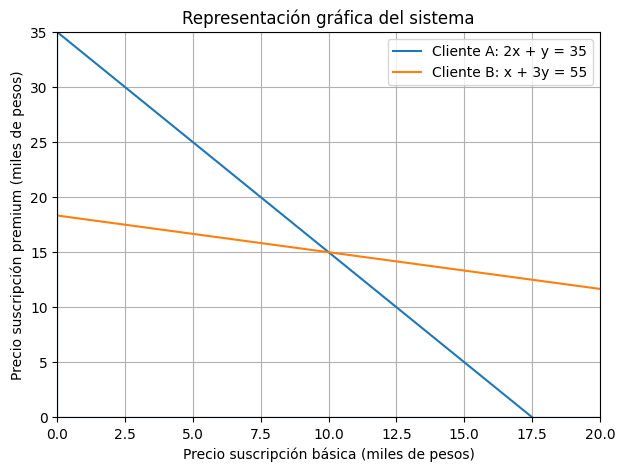

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 20, 200)

y_cliente_A = 35 - 2*x
y_cliente_B = (55 - x) / 3

plt.figure(figsize=(7, 5))

plt.plot(x, y_cliente_A, label="Cliente A: 2x + y = 35")
plt.plot(x, y_cliente_B, label="Cliente B: x + 3y = 55")

plt.xlabel("Precio suscripción básica (miles de pesos)")
plt.ylabel("Precio suscripción premium (miles de pesos)")
plt.title("Representación gráfica del sistema")

plt.xlim(0, 20)
plt.ylim(0, 35)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.grid()
plt.legend()

plt.show()

Las dos rectas se intersectan en un único punto, $(10, 15)$, cuyas coordenadas coinciden con las componentes del vector. Por lo tanto, el sistema tiene una única solución. Esto indica que las condiciones entregadas por ambos clientes aportan información suficiente para determinar un único precio para cada tipo de suscripción.

# **Actividad 2  - Costos de campañas digitales 📝**

Una empresa de marketing vende dos tipos de campañas: campañas en redes sociales y campañas en buscadores. Dos clientes contrataron distintas combinaciones y se conoce el costo total.

* Cliente 1: 3 campañas en redes sociales y 2 campañas en buscadores cuestan 470 mil pesos.
* Cliente 2: 2 campañas en redes sociales y 5 campañas en buscadores cuestan 680 mil pesos.

Sea:

$$x = \text{costo de una campaña en redes sociales}$$

$$y = \text{costo de una campaña en buscadores}$$

a) Plantee el sistema de ecuaciones.

$$3x+2y=470$$

$$2x+5y=680$$

b) Escriba la matriz de coeficientes $A$, el vector de incógnitas $x$ y el vector de resultados $b$.

$$\begin{pmatrix}
3 & 2 \\
2 & 5
\end{pmatrix}
\begin{pmatrix}
x \\
y
\end{pmatrix}
=
\begin{pmatrix}
470 \\
680
\end{pmatrix}$$

c) Dos analistas proponen los siguientes vectores de costos:

$$ v_1= \begin{pmatrix} 90\\ 100 \end{pmatrix} \qquad v_2= \begin{pmatrix} 100\\ 90 \end{pmatrix} $$

Calcule manualmente $Av_1$ y $Av_2$. Luego, determine cuál de las propuestas satisface el sistema y justifique su respuesta a partir de los productos calculados.

$$ Av_1= \begin{pmatrix} 3 & 2\\ 2 & 5 \end{pmatrix} \begin{pmatrix} 90\\ 100 \end{pmatrix} = \begin{pmatrix} 3\cdot(90)+2\cdot(100)\\ 2\cdot(90)+5\cdot(100) \end{pmatrix} = \begin{pmatrix} 270+200\\ 180+500 \end{pmatrix} = \begin{pmatrix} 470\\ 680 \end{pmatrix} =b $$
<br>

$$ Av_2= \begin{pmatrix} 3 & 2\\ 2 & 5 \end{pmatrix} \begin{pmatrix} 100\\ 90 \end{pmatrix} = \begin{pmatrix} 3\cdot(100)+2\cdot(90)\\ 2\cdot(100)+5\cdot(90) \end{pmatrix} = \begin{pmatrix} 300+180\\ 200+450 \end{pmatrix} = \begin{pmatrix} 480\\ 650 \end{pmatrix} \neq b $$
<br>

La propuesta $v_1$ satisface el sistema porque $Av_1=b$. En cambio, $v_2$ no satisface las condiciones, ya que $Av_2 \neq b$.

d) Interprete la propuesta que satisface el sistema en el contexto del problema.

La propuesta que satisface ambas condiciones corresponde a un costo de 90 mil pesos por campaña en redes sociales y 100 mil pesos por campaña en buscadores.

# **Actividad 3 - Restricciones incompatibles en un servicio logístico 📝**

Una empresa de logística intenta determinar el costo de dos servicios: despacho estándar y despacho express. Sin embargo, los registros disponibles parecen no ser consistentes.

* Registro 1: 2 despachos estándar y 1 express cuestan 40 mil pesos.

* Registro 2: 4 despachos estándar y 2 express cuestan 90 mil pesos.

Sea:

$$x = \text{costo de un despacho estándar}$$

$$y = \text{costo de un despacho express}$$

a) Plantee el sistema y escríbalo en forma matricial $Ax = b$.

$$ \begin{pmatrix} 2 & 1\\ 4 & 2 \end{pmatrix} \begin{pmatrix} x\\ y \end{pmatrix} = \begin{pmatrix} 40\\ 90 \end{pmatrix} $$

b) Compare las dos filas de la matriz A. ¿Qué relación existe entre ellas? Si el segundo registro mantuviera la misma relación, ¿qué valor debería tener la segunda componente de b?

La segunda fila de $A$ es el doble de la primera:

$$ (4,2)=2\cdot(2,1) $$

Por lo tanto, para mantener la misma relación, el segundo resultado debería ser:

$$ 2\cdot(40)=80 $$

c) Compare el valor obtenido en el inciso anterior con la segunda componente del vector b. ¿Puede existir un vector de costos que satisfaga simultáneamente ambas condiciones?

No. Los coeficientes de la segunda condición son exactamente el doble de los de la primera, pero el costo registrado no mantiene esa relación. Por lo tanto, las condiciones son contradictorias y no existe un vector de costos que satisfaga simultáneamente ambas ecuaciones.

d) Observe la representación gráfica del sistema. ¿Qué característica de las rectas confirma la conclusión obtenida en el inciso anterior?

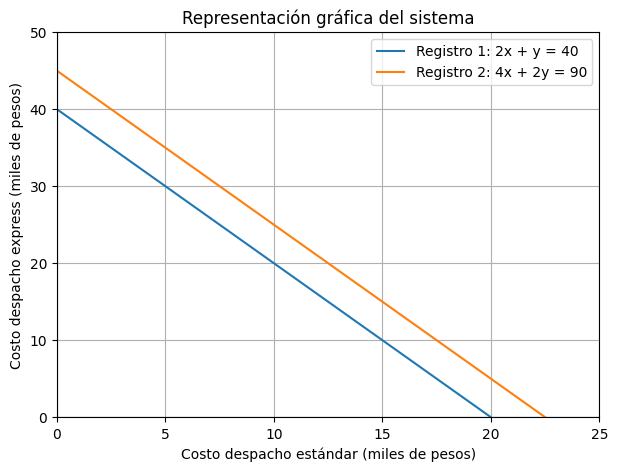

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 25, 200)

y_registro_1 = 40 - 2*x
y_registro_2 = 45 - 2*x

plt.figure(figsize=(7, 5))

plt.plot(x, y_registro_1, label="Registro 1: 2x + y = 40")
plt.plot(x, y_registro_2, label="Registro 2: 4x + 2y = 90")

plt.xlabel("Costo despacho estándar (miles de pesos)")
plt.ylabel("Costo despacho express (miles de pesos)")
plt.title("Representación gráfica del sistema")

plt.xlim(0, 25)
plt.ylim(0, 50)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.grid()
plt.legend()

plt.show()

Las rectas son paralelas y distintas, por lo que no presentan ningún punto de intersección. Gráficamente, esto confirma que no existe un par $(x, y)$ que satisfaga simultáneamente ambos registros.

e) Interprete el resultado en el contexto del problema.

El sistema no tiene solución porque los datos son incompatibles. El segundo registro debería costar 80 mil pesos si siguiera la misma lógica del primero, pero aparece como 90 mil pesos.

En contexto, esto podría indicar un error de registro, un cargo adicional no informado o que el modelo de costos no está considerando alguna variable relevante.

# **Actividad 4 - Restricciones redundantes en planes de almacenamiento 📝**

Una empresa vende dos tipos de almacenamiento en la nube: almacenamiento básico y almacenamiento avanzado.

* Cliente 1: 2 planes básicos y 3 avanzados cuestan 120 mil pesos.
* Cliente 2: 4 planes básicos y 6 avanzados cuestan 240 mil pesos.

Sea:

$$x = \text{costo de un plan básico}$$

$$y = \text{costo de un plan avanzado}$$

a) Plantee el sistema y escríbalo en forma matricial $Ax=b$.

$$ \begin{pmatrix} 2 & 3\\ 4 & 6 \end{pmatrix} \begin{pmatrix} x\\ y \end{pmatrix} = \begin{pmatrix} 120\\ 240 \end{pmatrix} $$

b) Compare las dos filas de $A$ y las componentes de $b$. ¿Qué relación observa entre ambas condiciones?

La segunda fila de A es el doble de la primera y la segunda componente de b también es el doble de la primera:

$$(4,6) = 2\cdot(2,3)$$

$$240 = 2\cdot(120)$$

Por lo tanto, la segunda condición no aporta información nueva; repite la misma relación de la primera.

c) Considere los siguientes vectores de precios:

$$ v_1 = \begin{pmatrix} 15 \\ 30 \end{pmatrix} \qquad v_2 = \begin{pmatrix} 30 \\ 20 \end{pmatrix} $$

Determine mediante el producto matriz-vector cuál de los vectores satisface el sistema.

$$ Av_1= \begin{pmatrix} 2 & 3\\ 4 & 6 \end{pmatrix} \begin{pmatrix} 15\\ 30 \end{pmatrix} = \begin{pmatrix} 2\cdot(15)+3\cdot(30)\\ 4\cdot(15)+6\cdot(30) \end{pmatrix} = \begin{pmatrix} 30+90\\ 60+180 \end{pmatrix} = \begin{pmatrix} 120\\ 240 \end{pmatrix} =b $$
<br>

$$ Av_2= \begin{pmatrix} 2 & 3\\ 4 & 6 \end{pmatrix} \begin{pmatrix} 30\\ 20 \end{pmatrix} = \begin{pmatrix} 2\cdot(30)+3\cdot(20)\\ 4\cdot(30)+6\cdot(20) \end{pmatrix} = \begin{pmatrix} 60+60\\ 120+120 \end{pmatrix} = \begin{pmatrix} 120\\ 240 \end{pmatrix} =b $$

d) Observe la representación gráfica del sistema y la ubicación de los vectores $v_1$ y $v_2$. ¿Qué relación existe entre las dos rectas y qué permite concluir respecto de las soluciones del sistema?

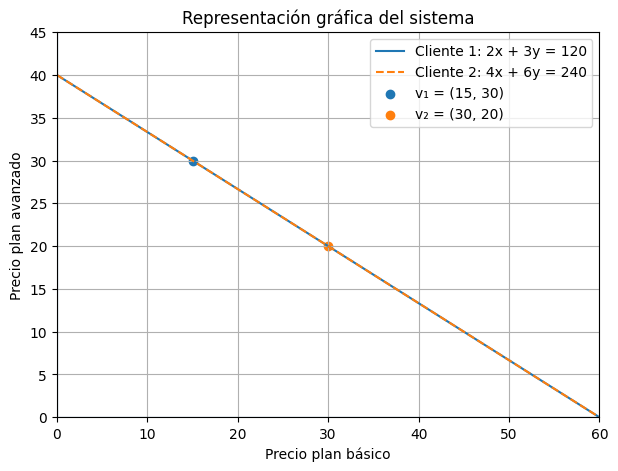

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 60, 200)

y_1 = (120 - 2*x) / 3
y_2 = (240 - 4*x) / 6

plt.figure(figsize=(7, 5))

plt.plot(x, y_1, label="Cliente 1: 2x + 3y = 120")
plt.plot(x, y_2, "--", label="Cliente 2: 4x + 6y = 240")

plt.scatter(15, 30, label="v₁ = (15, 30)")
plt.scatter(30, 20, label="v₂ = (30, 20)")

plt.xlabel("Precio plan básico")
plt.ylabel("Precio plan avanzado")
plt.title("Representación gráfica del sistema")

plt.xlim(0, 60)
plt.ylim(0, 45)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.grid()
plt.legend()

plt.show()

Las dos ecuaciones representan la misma recta y los puntos asociados a $v_1$ y $v_2$ se encuentran sobre ella. Esto confirma que ambos vectores son soluciones y que el sistema tiene infinitas soluciones.

# **Actividad 5 - Resolución de un sistema $2 \times 2$ con Python 💻🐍**

Una plataforma digital desea determinar los precios de suscripciones básica y premium usando el sistema trabajado en la Actividad 1:

$$2x+y=35$$

$$x+3y=55$$

a) Represente la matriz $A$ y el vector $b$ en Python.

In [ ]:
import numpy as np

# Matriz de coeficientes
A = np.array([
    [2, 1],
    [1, 3]
])

# Vector de resultados
b = np.array([35, 55])

b) Resuelva el sistema usando `np.linalg.solve`.

In [ ]:
# Nota: np.linalg.solve se utiliza para resolver sistemas Ax = b
# cuando A es cuadrada y el sistema tiene solución única.
# Es decir, si la matriz A es cuadrada y su rango es igual al número de incógnitas.

# Resolver sistema
x = np.linalg.solve(A, b)

print("Solución del sistema:")
print(x)

Solución del sistema:
[10. 15.]


c) Verifique el resultado calculando $A@x$.

In [ ]:
# Verificación
verificacion = A @ x

print("\nVerificación A @ x:")
print(verificacion)

print("\nVector b:")
print(b)


Verificación A @ x:
[35. 55.]

Vector b:
[35 55]


d) Interprete la solución.

La solución obtenida es: $x=10$ e $y=15$.

Esto significa que la suscripción básica cuesta 10 mil pesos y la premium 15 mil pesos. La verificación $A@x$ reproduce el vector $b$, por lo que la solución satisface las condiciones del problema.

# **Actividad 6 - Resolución de un sistema $3 \times 3$ con Python 💻🐍**

Una empresa digital analiza la distribución de horas en tres tipos de tareas:

* $x$ = tiempo destinado al diseño, medido en horas.
* $y$ = tiempo destinado a la programación, medido en horas.
* $z$ = tiempo destinado a las pruebas, medido en horas.
<br>

El sistema es:

$$2x+y+z=70$$

$$x+2y+z=80$$

$$x+y+2z=90$$

a) Represente el sistema en Python.

In [ ]:
import numpy as np

A = np.array([
    [2, 1, 1],
    [1, 2, 1],
    [1, 1, 2]
])

b = np.array([70,
              80,
              90])

b) Resuelva el sistema con `np.linalg.solve`.

In [ ]:
solucion = np.linalg.solve(A, b)

print("Solución:")
print(solucion)

Solución:
[10. 20. 30.]


c) Verifique el resultado.

In [ ]:
print("\nVerificación A @ solucion:")

print(A @ solucion)


Verificación A @ solucion:
[70. 80. 90.]


d) Interprete el resultado en el contexto del problema.

El resultado representa las horas correspondientes para cada tipo de tarea:

* diseño: 10 horas;
* programación: 20 horas;
* pruebas: 30 horas.

La verificación confirma que estos valores satisfacen las tres ecuaciones del sistema.

# **Actividad 7 - Sistema incompatible y análisis con rango 💻🐍**

Retomando el caso de la empresa de logística de la Actividad 3, se desea analizar computacionalmente si los registros disponibles son compatibles para determinar los costos del despacho estándar $x$ y del despacho express $y$:

$$2x+y=40$$

$$4x+2y=90$$

a)	Represente en Python la matriz de coeficientes $A$ y el vector $b$.

In [ ]:
import numpy as np

A = np.array([
    [2, 1],
    [4, 2]])

b = np.array([40,
              90])

b) En una celda de texto, escriba la matriz aumentada $[A∣b]$, incorporando el vector $b$ como última columna de $A$. Luego, constrúyala en Python y muestre el resultado.

**Nota:** Puede utilizar `np.column_stack((A, b))` para agregar $b$ como una nueva columna de $A$.


La matriz aumentada $[A|b]$ se construye incorporando el vector $b$ como una columna adicional de la matriz de coeficientes $A$.

Entonces la matriz aumentada es:

$$
[A|b]=
\begin{pmatrix}
2 & 1 & 40\\
4 & 2 & 90
\end{pmatrix}
$$

Esta matriz permite analizar simultáneamente los coeficientes del sistema y los resultados asociados a cada ecuación.

In [ ]:
# Construcción de la matriz aumentada [A|b]

A_aumentada = np.column_stack((A, b))

print("Matriz aumentada [A|b]:")
print(A_aumentada)

Matriz aumentada [A|b]:
[[ 2  1 40]
 [ 4  2 90]]


c) Calcule el rango de $A$ y de la matriz aumentada $[A \mid b]$.

In [ ]:
# Rango de A
rango_A = np.linalg.matrix_rank(A)

# Matriz aumentada [A|b]
A_aumentada = np.column_stack((A, b))
rango_A_aumentada = np.linalg.matrix_rank(A_aumentada)

print("Rango de A:", rango_A)
print("Rango de [A|b]:", rango_A_aumentada)
print("Número de incógnitas:", A.shape[1])

Rango de A: 1
Rango de [A|b]: 2
Número de incógnitas: 2


d)	Compare los rangos obtenidos. ¿Qué permite concluir respecto de las soluciones del sistema?

Como $\mathrm{rango}(A)=1$ y $\mathrm{rango}([A \mid b])=2$, los rangos son diferentes. Por lo tanto, el sistema es incompatible y no tiene solución; los registros son contradictorios.

# **Actividad 8 - Sistema con infinitas soluciones 💻🐍**

Retomando el caso de la empresa de almacenamiento en la nube (Actividad 4), se desea analizar computacionalmente las condiciones planteadas para los planes básico $x$ y avanzado $y$:

$$2x+3y=120$$

$$4x+6y=240$$

a) Represente en Python la matriz de coeficientes $A$ y el vector $b$.

In [ ]:
import numpy as np

A = np.array([
    [2, 3],
    [4, 6]
])

b = np.array([120,
              240])

b) Calcule el rango de $A$.

In [ ]:
rango_A = np.linalg.matrix_rank(A)
print("Rango de A:", rango_A)

Rango de A: 1


c) Calcule el rango de $[A \mid b]$.

In [ ]:
A_aumentada = np.column_stack((A, b))

rango_A_aumentada = np.linalg.matrix_rank(A_aumentada)
n_incognitas = A.shape[1]

print("Rango de [A|b]:", rango_A_aumentada)
print("Número de incógnitas:", n_incognitas)

Rango de [A|b]: 1
Número de incógnitas: 2


d) Determine el tipo de solución.

Cuando:

$\text{rango}(A)= \text{rango}([A \mid b]) < n$

el sistema tiene infinitas soluciones.


e) Interprete el resultado.

En este caso, las ecuaciones entregan información redundante. La empresa no puede determinar de forma única los precios de los planes solo con estos datos; necesita una condición adicional independiente.

# **Actividad 9 - Costos de recursos en la nube 📝**

Una empresa tecnológica revisa los costos asociados a tres recursos utilizados en sus servicios en la nube. Sea $x$ el costo de una unidad de cómputo, $y$ el costo de una unidad de almacenamiento y $z$ el costo de una unidad de soporte, todos medidos en miles de pesos. A partir de distintas combinaciones de estos recursos, el equipo organiza la información disponible mediante la siguiente representación matricial:

$$
\begin{pmatrix}
1 & 1 & 1 \\
0 & 1 & 1 \\
0 & 0 & 1
\end{pmatrix}
\begin{pmatrix}
x \\
y \\
z
\end{pmatrix}
=
\begin{pmatrix}
100 \\
70 \\
20
\end{pmatrix}
$$

a)	Determine manualmente los valores de $x$, $y$ y $z$.

De la tercera fila de la representación matricial se obtiene:

$$z=20$$

De la segunda fila de la representación matricial se obtiene:

$$y+z=70$$

$$y+20=70$$

$$y=50$$

De la primera fila de la representación matricial se obtiene:

$$x+y+z=100$$

$$x+50+20=100$$

$$x=30$$

b)	Interprete los valores obtenidos en el contexto del problema.

Los costos unitarios son $x=30$, $y=50$ y $z=20$. Es decir, una unidad de cómputo cuesta 30 mil pesos, una unidad de almacenamiento cuesta 50 mil pesos y una unidad de soporte cuesta 20 mil pesos.

# **Actividad 10 - Paquetes de servicios tecnológicos 📝**

Una empresa tecnológica ofrece tres tipos de servicios: básico, estándar y premium. Para revisar su estructura de precios, dispone de información sobre distintas combinaciones de estos servicios. Sea $x$ el costo del servicio básico, $y$ el costo del servicio estándar y $z$ el costo del servicio premium, todos medidos en miles de pesos.
La información disponible se representa mediante:

$$
\begin{pmatrix}
1 & 1 & 1 \\
0 & 2 & 1 \\
0 & 0 & 1
\end{pmatrix}
\begin{pmatrix}
x \\
y \\
z
\end{pmatrix}
=
\begin{pmatrix}
100 \\
110 \\
50
\end{pmatrix}
$$

a) A partir de la representación matricial, determine manualmente los valores de $x$, $y$ y $z$. Muestre su procedimiento y exprese la solución obtenida como un vector de precios $p$.

De la tercera fila de la representación matricial se obtiene:

$$z = 50$$

Luego, reemplazamos este valor en la segunda fila de la representación matricial:

$$2y + z = 110$$

$$2y + 50 = 110$$

$$2y = 60$$

$$y = 30$$

Finalmente, reemplazamos $y=30$ y $z=50$ en la primera fila de la representación matricial:

$$x + y + z = 100$$

$$x + 30 + 50 = 100$$

$$x + 80 = 100$$

$$x = 20$$

Por lo tanto, los costos de los servicios son:

$$x=20,\qquad y=30,\qquad z=50$$

La solución se puede expresar como vector de precios:

$$p =
\begin{pmatrix}
20\\
30\\
50
\end{pmatrix}$$

b)	Interprete los valores obtenidos en el contexto del problema.

Los valores de los servicios son: $x=20$, $y=30$ y $z=50$.

Como los valores están expresados en miles de pesos, esto significa que:

- el servicio básico cuesta 20 mil pesos;
- el servicio estándar cuesta 30 mil pesos;
- el servicio premium cuesta 50 mil pesos.

c)	Después de determinar los precios anteriores, la empresa informa que solo uno de los tres servicios modificó su precio.
Se registraron las siguientes contrataciones después de la actualización:

$$ r_1 = \begin{pmatrix} 2 \\ 1 \\ 1 \end{pmatrix} \qquad r_2 = \begin{pmatrix} 1 \\ 2 \\ 1 \end{pmatrix} $$

La primera contratación tuvo un costo total de 125 mil pesos y la segunda, de 140 mil pesos.

Utilice el vector de precios obtenido anteriormente para calcular cuánto habrían costado ambas contrataciones antes de la actualización. A partir de la diferencia con los nuevos valores, determine qué servicio modificó su precio y cuál es su nuevo valor. Justifique su respuesta.


Con el vector de precios original:

$$p = \begin{pmatrix} 20\\ 30\\ 50 \end{pmatrix}$$

Para la primera contratación:

$$r_1 \cdot p = 2\cdot(20)+1\cdot(30)+1\cdot(50)=120$$

El nuevo costo es 125 mil pesos, por lo que aumentó en:

$$125-120=5$$

Para la segunda contratación:

$$r_2 \cdot p = 1\cdot(20)+2\cdot(30)+1\cdot(50)=130$$

El nuevo costo es 140 mil pesos, por lo que aumentó en:

$$140-130=10$$

Como la primera contratación contiene **una unidad del servicio estándar** y su costo aumenta en 5 mil pesos, mientras que la segunda contiene **dos unidades del servicio estándar** y su costo aumenta en 10 mil pesos, el servicio que modificó su precio es el estándar.

Su precio aumentó en 5 mil pesos:

$$30+5=35$$

# **Actividad 11 - Consistencia de registros en un sistema de monitoreo 📝**

Un equipo de operaciones de datos utiliza tres indicadores para calcular un puntaje técnico asociado a cada ejecución de un proceso. Los indicadores corresponden, respectivamente, al nivel de retraso de procesamiento, incidencias detectadas y reintentos de tareas, y han sido todos expresados previamente en una escala común.

El equipo desea comprobar si los puntajes registrados pueden obtenerse mediante una misma regla lineal, cuyas ponderaciones desconocidas se representan mediante el vector

$$w = \begin{pmatrix} w_1\\ w_2\\ w_3 \end{pmatrix}$$

Los registros disponibles se organizan mediante:

$$R= \begin{pmatrix} 1 & 2 & 1\\ 2 & 1 & 0\\ 0 & 1 & 2\\ 3 & 3 & 1\end{pmatrix},
\qquad
s=\begin{pmatrix} 15\\ 11\\ 13\\ 29 \end{pmatrix}$$

Suponga que, si la regla existe, debe cumplirse exactamente para los cuatro registros.

a) Escriba la relación matricial que debe cumplirse para que un mismo vector de ponderaciones $w$ reproduzca los cuatro puntajes registrados. Indique las dimensiones de $R$, $w$ y $s$.

$$Rw=s$$

con $R_{4\times 3},\quad w_{3\times 1}\quad \text{y}\quad s_{4\times 1}$

b)	A continuación, se entrega el análisis realizado por otro integrante del equipo:

<p align="center">
<img src="https://i.ibb.co/Zy4DS7M/ACT-11.png">
</p>

Identifique qué herramienta presente utiliza el código para analizar el sistema. A partir de las salidas, determine si existe un único vector de ponderaciones $w$ que permita reproducir simultáneamente los cuatro puntajes. Justifique.

El código utiliza el rango de la matriz de coeficientes y de la matriz aumentada.

Como

$$\operatorname{rango}(R)=3$$

y

$$\operatorname{rango}([R \mid s])=4,$$

los rangos son diferentes. Por lo tanto, el sistema es incompatible y no existe un vector $w$ que reproduzca simultáneamente los cuatro puntajes registrados.

c) Sin resolver el sistema, compare las filas de $R$. Identifique una relación entre la cuarta fila y las filas anteriores. Si esa misma relación se mantuviera en $s$, ¿qué valor debería tener la cuarta componente?

La cuarta fila de $R$ corresponde a la suma de las dos primeras:

$$(1,2,1)+(2,1,0)=(3,3,1)$$

Por lo tanto, la cuarta componente de $s$ debería mantener la misma relación:

$$15+11=26$$


d) Compare el valor obtenido en el inciso anterior con la cuarta componente del vector s. ¿Qué indica esta comparación sobre las condiciones del sistema? Relacione su conclusión con los rangos entregados por el código y clasifique el sistema.

Al comparar la cuarta componente de $s$, se observa que el valor esperado sería $26$, pero el valor registrado es $29$:

$$29 \neq 26$$

Esto indica que las condiciones son contradictorias. Además, los resultados del código muestran que:

$$\operatorname{rango}(R)=3
\qquad \text{y} \qquad
\operatorname{rango}([R \mid s])=4$$

Como:

$$\operatorname{rango}(R) < \operatorname{rango}([R \mid s])$$

el sistema es incompatible y no tiene solución.

e) El equipo confirma que la cuarta componente del vector s contiene un error de registro y que su valor correcto es 26. Después de corregir el registro, se ejecuta nuevamente el análisis y se obtienen las siguientes salidas:

<p align="center">
<img src="https://i.ibb.co/03qjBqX/ACT-11-e.png">
</p>

Utilice estos resultados para clasificar el sistema y determine si la información disponible es suficiente para obtener un único vector de ponderaciones $w$. Justifique.

Después de la corrección:

$$\operatorname{rango}(R)=\operatorname{rango}([R \mid s])=3$$

Como el sistema tiene tres incógnitas y ambos rangos son iguales a $3$, el sistema tiene solución única. Por lo tanto, la información disponible es suficiente para determinar un único vector de ponderaciones $w$.

# **Actividad 12 - Combinación de recursos para un proyecto digital 📝**

Una empresa planifica la distribución del tiempo de trabajo en un proyecto digital. Sea $x$ el tiempo destinado al diseño, $y$ el tiempo destinado a la programación y $z$ el tiempo destinado a las pruebas, todos medidos en horas.

Para el proyecto se establecen las siguientes condiciones:

$$
2x+y+z=70,\qquad z=y+10,\qquad y=x+20.
$$

Un integrante del equipo representa las condiciones y utiliza Python para resolver el sistema:

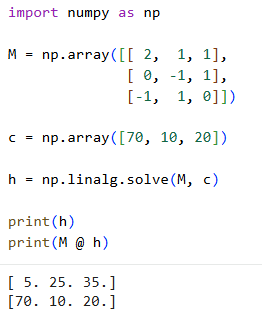

a) Determine cuánto tiempo del proyecto se destina a programación.

La primera salida corresponde a la solución del sistema:

$$
h=
\begin{pmatrix}
5\\
25\\
35
\end{pmatrix}
$$

Como la segunda componente corresponde a $y$, se destinan 25 horas a programación.

b) Un integrante del equipo afirma que la segunda salida corresponde a una nueva solución del sistema. ¿Es correcta esta afirmación? Justifique brevemente y explique qué permite concluir dicha salida respecto del vector $h$.

No. La segunda salida corresponde al producto $Mh$. Como coincide con el vector

$$c=
\begin{pmatrix}
70\\
10\\
20
\end{pmatrix}$$

confirma que el vector $h$ satisface las condiciones del sistema.

c) Durante la planificación, el equipo modifica únicamente la primera condición: ahora se establece:

$$2x + y + z = 82$$

mientras se mantienen las otras dos relaciones. Sin utilizar Python, determine los nuevos tiempos destinados al diseño, programación y pruebas. Compare el nuevo vector de tiempos con el obtenido originalmente.


Como se mantienen:

$$y=x+20$$

y

$$z=y+10=x+30$$

la nueva condición queda:

$$2x+(x+20)+(x+30)=82$$

Entonces:

$$4x+50=82$$

$$x=8$$

Por lo tanto:

$$y=28,\qquad z=38$$

El nuevo vector de tiempos es:

$$
h_{\text{nuevo}}=
\begin{pmatrix}
8\\
28\\
38
\end{pmatrix}$$

Comparado con el vector original, los tres tiempos aumentan en 3 horas.

# **Actividad 13 - Clasificación automática de sistemas 💻🐍**

Un equipo de análisis recibe distintos conjuntos de registros que generan sistemas lineales con diferentes cantidades de condiciones e incógnitas. Antes de intentar resolverlos, desea construir una función en Python que permita determinar automáticamente si la información disponible conduce a una solución única, no tiene solución o admite infinitas soluciones.

a) Cree una función llamada `clasificar_sistema(A, b)` que reciba la matriz A y el vector b, calcule el rango de A y de la matriz aumentada $[A \mid b]$, y clasifique el sistema como de solución única, sin solución o con infinitas soluciones.

In [6]:
import numpy as np

def clasificar_sistema(A, b):
    """Clasifica un sistema lineal comparando el rango de A,
    el rango de la matriz aumentada [A|b] y el número de incógnitas."""

    # Asegurar que b sea una columna
    b = np.asarray(b).reshape(-1, 1)

    # Construir matriz aumentada [A|b]
    A_aumentada = np.column_stack((A, b))

    # Calcular rangos
    rango_A = np.linalg.matrix_rank(A)
    rango_A_aumentada = np.linalg.matrix_rank(A_aumentada)

    # Número de incógnitas
    n_incognitas = A.shape[1]

    print("Rango de A:", rango_A)
    print("Rango de [A|b]:", rango_A_aumentada)
    print("Número de incógnitas:", n_incognitas)

    if rango_A != rango_A_aumentada:
        return "El sistema no tiene solución."

    elif rango_A == rango_A_aumentada and rango_A == n_incognitas:
        return "El sistema tiene solución única."

    elif rango_A == rango_A_aumentada and rango_A < n_incognitas:
        return "El sistema tiene infinitas soluciones."

b) Pruebe la función con los siguientes sistemas:

**Sistema 1**

$$
\left\{
\begin{aligned}
2x-y+3z+w &= 17\\
x+4y-2z &= -6\\
-3x+2y+z+5w &= 21\\
4x-z+2w &= 9
\end{aligned}
\right.
$$

**Sistema 2**

$$
\left\{
\begin{aligned}
3x-2y+z &= 11\\
-x+4y+2z &= 0\\
2x+y-3z &= -6\\
5x-y &= 11\\
-2x+3y+4z &= 5
\end{aligned}
\right.
$$

**Sistema 3**

$$
\left\{
\begin{aligned}
3x-2y+z &= 11\\
-x+4y+2z &= 0\\
2x+y-3z &= -6\\
5x-y &= 11\\
-2x+3y+4z &= 8
\end{aligned}
\right.
$$

**Sistema 4**

$$
\left\{
\begin{aligned}
2x-y+3u+v &= 7\\
4y-2z+u-3v &= -2\\
-x+2y+5z+2v &= 12\\
3x-z-2u+4v &= 5
\end{aligned}
\right.
$$

c)	Para cada sistema, interprete los valores entregados por la función y justifique la clasificación obtenida.

In [ ]:
# Sistema 1

A1 = np.array([
    [2, -1, 3, 1],
    [1, 4, -2, 0],
    [-3, 2, 1, 5],
    [4, 0, -1, 2]
])

b1 = np.array([17, -6, 21, 9])

print(clasificar_sistema(A1, b1))

Rango de A: 4
Rango de [A|b]: 4
Número de incógnitas: 4
El sistema tiene solución única.


Sistema 1: $\text{rango}(A) = \text{rango}([A∣b])=4$ y hay 4 incógnitas. Por lo tanto, tiene solución única.

In [ ]:
# Sistema 2

A2 = np.array([
    [ 3, -2,  1],
    [-1,  4,  2],
    [ 2,  1, -3],
    [ 5, -1,  0],
    [-2,  3,  4]
])

b2 = np.array([11, 0, -6, 11, 5])

print(clasificar_sistema(A2, b2))

Rango de A: 3
Rango de [A|b]: 3
Número de incógnitas: 3
El sistema tiene solución única.


Sistema 2: $\text{rango}(A) = \text{rango}([A∣b])=3$ y hay 3 incógnitas. Por lo tanto, tiene solución única.

In [ ]:
# Sistema 3

A3 = np.array([
    [ 3, -2,  1],
    [-1,  4,  2],
    [ 2,  1, -3],
    [ 5, -1,  0],
    [-2,  3,  4]
])

b3 = np.array([11, 0, -6, 11, 8])

print(clasificar_sistema(A3, b3))


Rango de A: 3
Rango de [A|b]: 4
Número de incógnitas: 3
El sistema no tiene solución.


Sistema 3: $\text{rango}(A)=3 < 4 = \text{rango}([A∣b])$. Por lo tanto, el sistema es incompatible y no tiene solución.

In [ ]:
# Sistema 4

A4 = np.array([
    [ 2, -1,  0,  3,  1],
    [ 0,  4, -2,  1, -3],
    [-1,  2,  5,  0,  2],
    [ 3,  0, -1, -2,  4]
])

b4 = np.array([7, -2, 12, 5])

print(clasificar_sistema(A4, b4))

Rango de A: 4
Rango de [A|b]: 4
Número de incógnitas: 5
El sistema tiene infinitas soluciones.


Sistema 4: $\text{rango}(A) = \text{rango}([A∣b])=4$, pero hay 5 incógnitas. Por lo tanto, tiene infinitas soluciones.

d)	Compare los resultados de los sistemas 2 y 3. Si ambos utilizan la misma matriz de coeficientes, ¿por qué pueden tener distinto tipo de solución? Fundamente su respuesta utilizando las salidas de la función.

Ambos sistemas tienen el mismo rango de la matriz de coeficientes: $\text{rango}(A_2)=\text{rango}(A_3)=3$. Sin embargo, en el sistema 2 la matriz aumentada también tiene rango 3, mientras que en el sistema 3 su rango aumenta a 4. Por lo tanto, el cambio en el vector de resultados hace que las condiciones del sistema 3 sean incompatibles, aunque la matriz de coeficientes sea la misma.

# **Actividad 14 - Consistencia de tiempos de atención 💻🐍**

Un equipo de soporte técnico analiza el tiempo requerido para atender tres tipos de solicitudes:

* $x$: tiempo promedio de atención de una solicitud básica, medido en minutos;
* $y$: tiempo promedio de atención de una solicitud de configuración, medido en minutos;
* $z$: tiempo promedio de atención de una solicitud de escalamiento, medido en minutos.

Durante seis turnos se registró la cantidad de solicitudes atendidas de cada tipo y el tiempo total utilizado:

$$\begin{array}{|c|c|c|c|c|}
\hline
\text{Turno} & \text{Básicas} & \text{Configuración} & \text{Escalamiento} & \text{Tiempo total (min)} \\
\hline
1 & 4 & 2 & 1 & 123 \\
\hline
2 & 1 & 3 & 2 & 142 \\
\hline
3 & 3 & 1 & 4 & 196 \\
\hline
4 & 2 & 5 & 1 & 159 \\
\hline
5 & 5 & 2 & 3 & 205 \\
\hline
6 & 2 & 2 & 2 & 139 \\
\hline
\end{array}$$

Suponga que los tiempos por tipo de solicitud se mantienen constantes entre los turnos.

a) Organice los seis registros en una matriz A y un vector b en Python. Luego, utilice la función `clasificar_sistema(A, b)` creada en la actividad anterior para determinar si existe un único vector de tiempos que satisfaga simultáneamente todos los registros.

In [ ]:
A = np.array([[4, 2, 1],
              [1, 3, 2],
              [3, 1, 4],
              [2, 5, 1],
              [5, 2, 3],
              [2, 2, 2]])

b = np.array([123, 142, 196, 159, 205, 139])

clasificar_sistema(A, b)

Rango de A: 3
Rango de [A|b]: 4
Número de incógnitas: 3


'El sistema no tiene solución.'

Como $\text{rango}(A) < \text{rango}([A∣b])$, los seis registros no son compatibles con un mismo vector de tiempos.

b)	Utilice un ciclo `for` para analizar qué ocurre con los rangos al incorporar progresivamente los registros, comenzando por los tres primeros. Determine a partir de qué turno el conjunto de datos deja de ser compatible.

In [ ]:
for k in range(3, len(b) + 1):
    print(f"\nTurnos 1 a {k}:")
    clasificar_sistema(A[:k], b[:k])


Turnos 1 a 3:
Rango de A: 3
Rango de [A|b]: 3
Número de incógnitas: 3

Turnos 1 a 4:
Rango de A: 3
Rango de [A|b]: 3
Número de incógnitas: 3

Turnos 1 a 5:
Rango de A: 3
Rango de [A|b]: 3
Número de incógnitas: 3

Turnos 1 a 6:
Rango de A: 3
Rango de [A|b]: 4
Número de incógnitas: 3


Los rangos se mantienen iguales al incorporar los turnos 1 a 5. Al incorporar el turno 6, el rango de la matriz aumentada aumenta a 4. Por lo tanto, el sexto registro introduce una contradicción con los registros anteriores.

c) Utilice los tres primeros registros para formar un sistema $3 \times 3$ y determine el tiempo promedio de atención correspondiente a cada tipo de solicitud.

In [ ]:
A_3 = A[:3]
b_3 = b[:3]

tiempos = np.linalg.solve(A_3, b_3)
print(tiempos)

[12. 20. 35.]


El tiempo promedio de atención es de 12 minutos para una solicitud básica, 20 minutos para una solicitud de configuración y 35 minutos para una solicitud de escalamiento.

# **Actividad 15 - Dataset de servicios tecnológicos 💻🐍**

Una empresa tecnológica desea determinar el costo unitario de tres componentes de sus servicios:

* horas de soporte técnico;
* licencias de software;
* almacenamiento en la nube (considera bloques de 100 GB por mes).

Cada cliente contrató distintas cantidades de estos componentes y se conoce el costo total facturado. Suponga que el costo total corresponde exactamente a la suma de las cantidades contratadas multiplicadas por costos unitarios fijos para cada componente.

Descargue el **<a href="https://drive.google.com/uc?export=download&id=1_6ZliX6D2BbWd7IWsv22yD58z8TuWnbb">set de datos</a>**.


a) Cargue el dataset y represente la información mediante una matriz $A$, formada por las cantidades contratadas de los tres componentes, y un vector $b$, formado por los costos totales.

In [ ]:
import numpy as np
import pandas as pd

df_servicios = pd.read_csv("L3_A15_servicios_tecnologicos.csv")

df_servicios.head()

,horas_soporte,licencias_software,almacenamiento_nube,costo_total
0,2,5,3,134000
1,4,3,2,152000
2,1,8,5,161000
3,3,6,4,179000
4,5,4,3,197000


In [ ]:
# Matriz de variables explicativas
A = df_servicios[
    ["horas_soporte", "licencias_software", "almacenamiento_nube"]
].to_numpy(dtype=float)

print("Dimensión de A:", A.shape)

Dimensión de A: (10, 3)


In [ ]:
# Vector de costo total
b = df_servicios["costo_total"].to_numpy(dtype=float).reshape(-1, 1)

print("Dimensión de b:", b.shape)

Dimensión de b: (10, 1)


b)	Utilice la función `clasificar_sistema()` creada anteriormente para analizar el sistema formado por todos los registros. A partir de las salidas, determine si los datos permiten obtener un único vector de costos unitarios. Justifique.

In [ ]:
print(clasificar_sistema(A,b))

Rango de A: 3
Rango de [A|b]: 3
Número de incógnitas: 3
El sistema tiene solución única.


El rango de A y el de $[A∣b]$ son iguales a 3, que corresponde al número de incógnitas. Por lo tanto, los registros son compatibles y permiten determinar un único vector de costos unitarios.

c)	Utilice los tres primeros registros para formar un sistema $3\times3$ y determine con Python los costos unitarios de los tres componentes. Exprese el resultado como un vector e interprételo en contexto.

In [ ]:
# Tomamos las tres primeras filas para resolver un sistema cuadrado
A_sistema = A[:3]
b_sistema = b[:3]

print("A_sistema:")
print(A_sistema)

print("\nb_sistema:")
print(b_sistema)

A_sistema:
[[2. 5. 3.]
 [4. 3. 2.]
 [1. 8. 5.]]

b_sistema:
[[134000.]
 [152000.]
 [161000.]]


$$A_{sistema} = \begin{pmatrix} 2 & 5 & 3\\ 4 & 3 & 2\\ 1 & 8 & 5\end{pmatrix}
\qquad
b_{sistema} =\begin{pmatrix} 134000\\ 152000\\ 161000 \end{pmatrix}$$

In [ ]:
# Llamamos a la función previamente creada en la Actividad 13
print(clasificar_sistema(A_sistema, b_sistema))

Rango de A: 3
Rango de [A|b]: 3
Número de incógnitas: 3
El sistema tiene solución única.


In [ ]:
# Resolver el sistema cuadrado 3 x 3
costos_calculados = np.linalg.solve(A_sistema, b_sistema)

print("Costos calculados:")
print(costos_calculados)

Costos calculados:
[[25000.]
 [12000.]
 [ 8000.]]


El vector de costos unitarios obtenido es:

$$
\begin{pmatrix}
25000 \\
12000 \\
8000
\end{pmatrix}
$$

Por lo tanto, el costo unitario de una hora de soporte técnico es de $\$ $25.000, el de una licencia de software es de $\$ $12.000 y el de un bloque de 100 GB de almacenamiento en la nube por mes es de $\$ $8.000.

d)	Utilice el vector de costos obtenido para calcular simultáneamente el costo correspondiente a todos los clientes del dataset. Compare los valores calculados con los costos registrados y determine qué permite concluir esta verificación.

**Nota**: Si la columna diferencia es igual a 0, o muy cercana a 0, significa que los costos unitarios calculados reproducen correctamente el costo total de todos los clientes del dataset.


In [ ]:
# Verificar costos calculados en todos los clientes del dataset
df_servicios["costos_calculados"] = A @ costos_calculados

# Diferencia entre el costo registrado y el costo calculado
df_servicios["diferencia"] = (
    df_servicios["costo_total"] - df_servicios["costos_calculados"]
)

# Redondear la diferencia para evitar valores como -0.0
df_servicios["diferencia"] = np.round(df_servicios["diferencia"], 2)

# Mostrar tabla con resultados
display(df_servicios.round(2))

,horas_soporte,licencias_software,almacenamiento_nube,costo_total,costos_calculados,diferencia
0,2,5,3,134000,134000.0,-0.0
1,4,3,2,152000,152000.0,0.0
2,1,8,5,161000,161000.0,0.0
3,3,6,4,179000,179000.0,-0.0
4,5,4,3,197000,197000.0,0.0
5,2,7,6,182000,182000.0,0.0
6,6,2,4,206000,206000.0,0.0
7,4,5,5,200000,200000.0,0.0
8,3,3,7,167000,167000.0,0.0
9,5,6,2,213000,213000.0,-0.0


In [ ]:
# Verificación final
if np.allclose(df_servicios["diferencia"], 0):
    print("Los costos calculados reproducen correctamente todos los costos totales del dataset.")
else:
    print("Existen diferencias entre los costos reales y los costos calculados.")

Los costos calculados reproducen correctamente todos los costos totales del dataset.


Al aplicar el vector de costos unitarios a todos los registros del dataset, los costos calculados coinciden con los costos totales observados. Las diferencias son iguales a 0 o muy cercanas a 0 debido al redondeo computacional. Por lo tanto, se concluye que los costos unitarios encontrados reproducen correctamente los costos facturados de todos los clientes del dataset.

# **Actividad 16 - Dataset de prioridad de tickets de soporte 💻🐍**

Una empresa tecnológica utiliza un puntaje de prioridad para ordenar la atención de tickets de soporte. El puntaje depende de cuatro variables:

*	tiempo de espera, medido en horas;
*	nivel de impacto, en una escala de 1 a 5;
*	cantidad de usuarios afectados;
*	nivel de criticidad, en una escala de 0 a 3.

La empresa utiliza una misma regla lineal para calcular el puntaje de prioridad de todos los tickets y desea determinar las ponderaciones asociadas a cada variable.

Descargue el **<a href="https://drive.google.com/uc?export=download&id=16Brp-U7Iq1ZYSon0hupELgxjoBXhrpWu">set de datos</a>** aquí.


a) Cargue el dataset y organice las cuatro variables de los tickets en una matriz $A$ y los puntajes de prioridad en un vector $b$.

In [7]:
import numpy as np
import pandas as pd

df_tickets = pd.read_csv("L3_A16_prioridad_tickets.csv")

display(df_tickets.head())

,tiempo_espera,impacto,usuarios_afectados,criticidad,puntaje_prioridad
0,2,1,10,0,9.0
1,4,2,20,1,24.0
2,6,4,30,1,37.0
3,8,5,50,2,54.0
4,3,2,15,1,21.5


In [2]:
A = df_tickets[
    ["tiempo_espera", "impacto", "usuarios_afectados", "criticidad"]
].to_numpy(dtype=float)

print("Dimensión de A:", A.shape)

Dimensión de A: (12, 4)


In [8]:
b = df_tickets["puntaje_prioridad"].to_numpy(dtype=float).reshape(-1, 1)

print("Dimensión de b:", b.shape)

Dimensión de b: (12, 1)


b) 	Utilice los tickets 1 al 4 y los tickets 5 al 8 para formar dos sistemas $4 \times 4$. Determine con la función `clasificar_sistema()` sí ambos sistemas admiten solución única. Luego, determine por separado el vector de ponderaciones asociado a cada sistema y compare los resultados obtenidos.

In [9]:
# Sistema 1: tickets 1 al 4
A_sistema_1 = A[:4]
b_sistema_1 = b[:4]

# Sistema 2: tickets 5 al 8
A_sistema_2 = A[4:8]
b_sistema_2 = b[4:8]

print("A_sistema_1:")
print(A_sistema_1)

print("\nb_sistema_1:")
print(b_sistema_1)

print("\nA_sistema_2:")
print(A_sistema_2)

print("\nb_sistema_2:")
print(b_sistema_2)

A_sistema_1:
[[ 2.  1. 10.  0.]
 [ 4.  2. 20.  1.]
 [ 6.  4. 30.  1.]
 [ 8.  5. 50.  2.]]

b_sistema_1:
[[ 9.]
 [24.]
 [37.]
 [54.]]

A_sistema_2:
[[ 3.  2. 15.  1.]
 [ 5.  3. 25.  1.]
 [ 7.  4. 40.  2.]
 [10.  5. 70.  3.]]

b_sistema_2:
[[21.5]
 [30.5]
 [46.5]
 [67. ]]


In [10]:
# Clasificar ambos sistemas
print("Clasificación del sistema con tickets 1 al 4:")
print(clasificar_sistema(A_sistema_1, b_sistema_1))

print("\nClasificación del sistema con tickets 5 al 8:")
print(clasificar_sistema(A_sistema_2, b_sistema_2))

Clasificación del sistema con tickets 1 al 4:
Rango de A: 4
Rango de [A|b]: 4
Número de incógnitas: 4
El sistema tiene solución única.

Clasificación del sistema con tickets 5 al 8:
Rango de A: 4
Rango de [A|b]: 4
Número de incógnitas: 4
El sistema tiene solución única.


In [11]:
# Resolver ambos sistemas 4 x 4
ponderaciones_calculadas_1 = np.linalg.solve(A_sistema_1, b_sistema_1)
ponderaciones_calculadas_2 = np.linalg.solve(A_sistema_2, b_sistema_2)

print("Ponderaciones calculadas con tickets 1 al 4:")
print(ponderaciones_calculadas_1)

print("\nPonderaciones calculadas con tickets 5 al 8:")
print(ponderaciones_calculadas_2)

Ponderaciones calculadas con tickets 1 al 4:
[[1.5]
 [4. ]
 [0.2]
 [6. ]]

Ponderaciones calculadas con tickets 5 al 8:
[[1.5]
 [4. ]
 [0.2]
 [6. ]]


La función indica que ambos sistemas tienen solución única. Al resolverlos, los dos subconjuntos producen el mismo vector de ponderaciones, por lo que son consistentes con una misma regla lineal de cálculo del puntaje.

c)	Interprete las ponderaciones obtenidas considerando las unidades o escalas de las variables.

Las ponderaciones indican que, manteniendo las demás variables sin cambio, el puntaje aumenta:

*	1,5 puntos por cada hora adicional de espera;
*	4 puntos por cada nivel adicional de impacto;
*	0,2 puntos por cada usuario adicional afectado;
*	6 puntos por cada nivel adicional de criticidad.


d)	Un ticket mantiene sin cambios su nivel de impacto y criticidad, pero su tiempo de espera aumenta en 2 horas y la cantidad de usuarios afectados aumenta en 10. Represente estos cambios mediante un vector y determine cuánto aumenta su puntaje de prioridad.

Desarrollo manual:

El cambio en las variables del ticket se representa mediante:

$$
\Delta x =
\begin{pmatrix}
2 \\
0 \\
10 \\
0
\end{pmatrix}
$$

y el vector de ponderaciones es:

$$
w =
\begin{pmatrix}
1,5 \\
4 \\
0,2 \\
6
\end{pmatrix}
$$

Entonces, mediante el producto punto:

$$
w^T \cdot \Delta x = 1,5(2) + 4(0) + 0,2(10) + 6(0)
= 5.
$$

Por lo tanto, el puntaje de prioridad aumenta en 5 puntos.

**Nota:** El símbolo $\Delta$ (delta) se utiliza para representar un cambio o variación. En este caso, $\Delta x$ representa el vector de cambios en las variables del ticket.

In [ ]:
import numpy as np

# Vector de ponderaciones calculado anteriormente
# Orden: [tiempo_espera, impacto, usuarios_afectados, criticidad]
w = np.array([1.5, 4, 0.2, 6])

# Vector de cambios del ticket
# Aumenta 2 horas el tiempo de espera
# No cambia el impacto
# Aumentan en 10 los usuarios afectados
# No cambia la criticidad
delta_x = np.array([2, 0, 10, 0])

# Cambio en el puntaje de prioridad
aumento_puntaje = delta_x @ w

print("Vector de cambio:")
print(delta_x)

print("\nAumento en el puntaje de prioridad:")
print(aumento_puntaje)

Vector de cambio:
[ 2  0 10  0]

Aumento en el puntaje de prioridad:
5.0


El puntaje de prioridad aumenta en 5 puntos.

# En este laboratorio aprendiste a…
* Plantear sistemas lineales desde problemas contextualizados.
* Representar sistemas en forma matricial $Ax=b$.
* Verificar si un vector propuesto satisface un sistema mediante el producto matriz-vector.
* Clasificar sistemas mediante el rango, reconociendo información suficiente, redundante o contradictoria.
* Utilizar Python para resolver, verificar y analizar sistemas lineales.
* Aplicar sistemas lineales a datos organizados en archivos CSV para determinar cantidades desconocidas y comprobar la consistencia de una regla lineal.
